In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
S={"student_id":[1,2,3,4,5,6,7], "student_name":["Ram","Seeta","Shyam","Geeta","Avika","Abhii","Deepanhsi"], "age":[19,18,19,20,18,19,18], "height":[160,162,165,162,162,161,160], "weight":[56,79,54,60,63,62,60],"semester":[2,2,2,2,2,None,2], "gender":['M',None,'M','F','F','M','F'], "city":["Rampur","Rudrapur",None,"Delhi","Raipur","Barielly","Pilibhit"] }
df=pd.DataFrame(S)
df

,student_id,student_name,age,height,weight,semester,gender,city
0,1,Ram,19,160,56,2.0,M,Rampur
1,2,Seeta,18,162,79,2.0,None,Rudrapur
2,3,Shyam,19,165,54,2.0,M,None
3,4,Geeta,20,162,60,2.0,F,Delhi
4,5,Avika,18,162,63,2.0,F,Raipur
5,6,Abhii,19,161,62,NaN,M,Barielly
6,7,Deepanhsi,18,160,60,2.0,F,Pilibhit


In [3]:
df["gender"].isnull()

0    False
1     True
2    False
3    False
4    False
5    False
6    False
Name: gender, dtype: bool

In [4]:
#shape of df.shape

In [5]:
#Names of columns
df.columns

Index(['student_id', 'student_name', 'age', 'height', 'weight', 'semester',
       'gender', 'city'],
      dtype='object')

In [6]:
#Number of NUll values in each columns
df.isnull().sum()

student_id      0
student_name    0
age             0
height          0
weight          0
semester        1
gender          1
city            1
dtype: int64

In [7]:
df['student_name'].unique()

array(['Ram', 'Seeta', 'Shyam', 'Geeta', 'Avika', 'Abhii', 'Deepanhsi'],
      dtype=object)

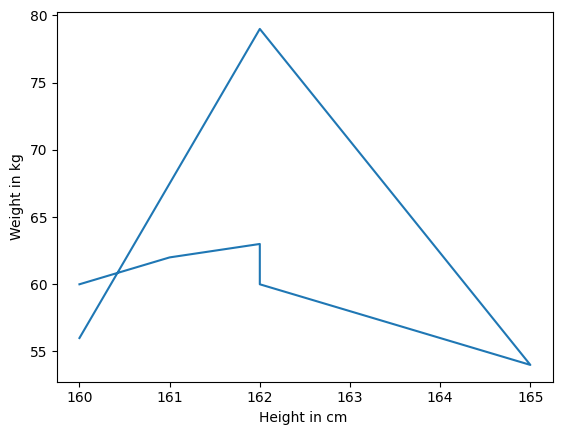

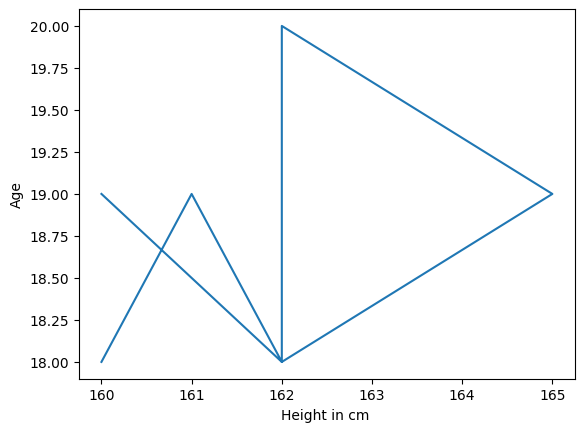

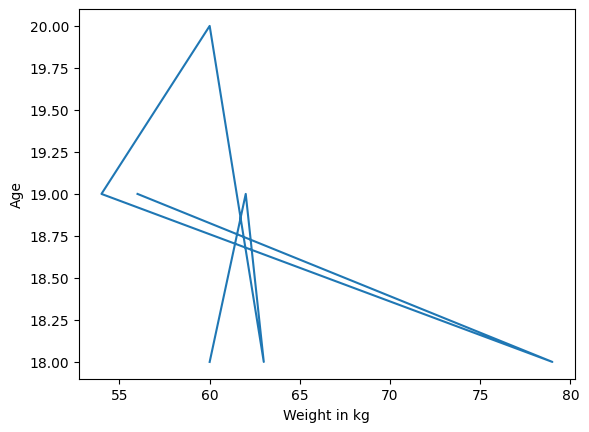

In [8]:
#v. Plot line graph between height and weight, height and age and weight and age.
plt.figure()
plt.plot(df['height'],df['weight'])
plt.xlabel("Height in cm ")
plt.ylabel("Weight in kg")
plt.show()
plt.figure()
plt.plot(df['height'],df['age'])
plt.xlabel("Height in cm ")
plt.ylabel("Age")
plt.show()
plt.figure()
plt.plot(df['weight'],df['age'])
plt.ylabel("Age")
plt.xlabel("Weight in kg")
plt.show()

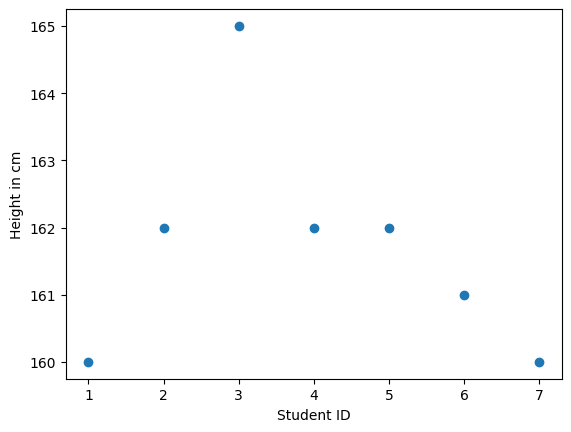

In [9]:
# Visualization of  the outliers present in height column using scatterplot.
plt.figure()
plt.scatter(df['student_id'],df['height'])
plt.xlabel("Student ID")
plt.ylabel("Height in cm")
plt.show()

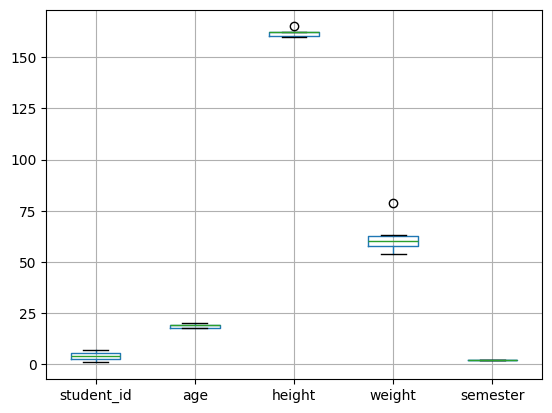

In [10]:
# Outlier in each column using boxplot.
numeric_df = df.select_dtypes(include=['number'])
plt.figure()
df.boxplot()
plt.show()


In [11]:
df.columns

Index(['student_id', 'student_name', 'age', 'height', 'weight', 'semester',
       'gender', 'city'],
      dtype='object')

In [12]:
# Remove outliers using IQR method
Q1=df["height"].quantile(0.25)
Q3=df["height"].quantile(0.75)
IQR=Q3-Q1
df=df[(df["height"]>Q1-1.5*IQR) & (df["height"]<Q3+1.5*IQR)]
print(df)

   student_id student_name  age  height  weight  semester gender      city
0           1          Ram   19     160      56       2.0      M    Rampur
1           2        Seeta   18     162      79       2.0   None  Rudrapur
3           4        Geeta   20     162      60       2.0      F     Delhi
4           5        Avika   18     162      63       2.0      F    Raipur
5           6        Abhii   19     161      62       NaN      M  Barielly
6           7    Deepanhsi   18     160      60       2.0      F  Pilibhit


In [13]:
#Remove outlier from weight column using z-score method.
mean=np.mean(df["weight"])
std=np.std(df["weight"])
df["z_score"]=(df["weight"]-mean)/std
df[np.abs(df["z_score"])<=3]

C:\Users\Deepanshi Agarwal\AppData\Local\Temp\ipykernel_20828\3713589628.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["z_score"]=(df["weight"]-mean)/std


,student_id,student_name,age,height,weight,semester,gender,city,z_score
0,1,Ram,19,160,56,2.0,M,Rampur,-0.998969
1,2,Seeta,18,162,79,2.0,None,Rudrapur,2.134160
3,4,Geeta,20,162,60,2.0,F,Delhi,-0.454077
4,5,Avika,18,162,63,2.0,F,Raipur,-0.045408
5,6,Abhii,19,161,62,NaN,M,Barielly,-0.181631
6,7,Deepanhsi,18,160,60,2.0,F,Pilibhit,-0.454077
